In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cpu')
# if torch.cuda.is_available():
#     device = torch.device('cuda:0')

print(seed, device)

42 cpu


### GENERATE SAMPLES

In [ ]:
# generate gaussian mixture with seperated means with equal weights

def generate_gaussian_mixture():
    n_samples = 5000
    weights = np.array([0.8, 0.2])
    means = [np.array([-0.5, -0.5]), np.array([0.5, 0.5])]
    cov = np.array([[0.01, 0.0], [0.0, 0.01]]) # I

    n1 = np.random.binomial(n_samples, weights[0])
    n2 = n_samples - n1

    s1 = np.random.multivariate_normal(means[0], cov, size=n1)
    s2 = np.random.multivariate_normal(means[1], cov, size=n2)

    return np.vstack([s1, s2])

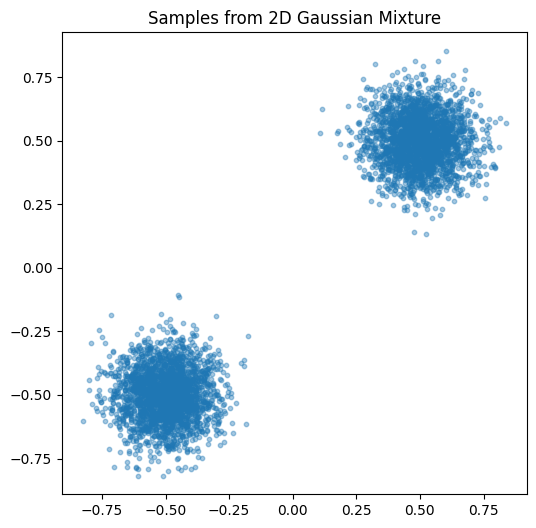

In [4]:
samples = generate_gaussian_mixture()

# Plot samples and contours
plt.figure(figsize=(6, 6))
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()

### DRIFT

In [5]:
# let's implement the distance function basically l2 distance
def distance(x, y):
    """
        x : torch tensor of shape N1, D
        y : torch tensor of shape N2, D
        returns : (N1, N2)
    """
    # (N1, 1, D) - (1, N2, D) -> (N1, N2, D)
    diff = x[:, None, :] - y[None, :, :]
    return torch.sqrt(torch.sum(diff ** 2, dim=-1))


def calculate_current_or_true_field(norm_kernel, samples, inp):
    """
        function that calculates Vp+ or Vq-.
        norm_kernel -> normalized kernel - either tildekp or tildekq
        samples -> samples from either p (true) or q (current)
        inp -> x which is basically current generated samples.

        norm_kernel -> (N, N_pos) or (N, N_neg)
        samples -> (N_pos, D) or (N_neg, D)
        inp -> (N, D)
    """
    # the shapes are written assuming that input is from true distribution. So pos will be used
    # similar shapes will be there for neg as well.

    # (1, N_pos, D) - (N, 1, D) -> (N, N_pos, D)
    v = samples[None, :, :] - inp[:, None, :]
    # (N, N_pos, 1) * (N, N_pos, D) -> (N, N_pos, D)
    v = norm_kernel[:, :, None] * v
    # (N, N_pos, D) -> (N, D)
    v = torch.mean(v, dim=1)

    return v


# calculate the drift term
# basically following Algorithm - 2 of the paper but I didn't like the normalization of x
# so I will be removing it and writing this code to understand. so may not be optimal
def calculate_drift(x, y_pos, y_neg, T, input_is_neg=False):
    """
        x = f(eps) - output from the network - (N, D)
        y_pos - sample from distribution p where p is data distribution - (N_pos, D)
        y_neg - samples from distribution q - (N_neg, D)
        T - temperature
        input_is_neg : boolean. It indicates if the current distribution points are same as input that is
        if x is equal to y_neg.
    """
    N_pos, N_neg = len(y_pos), len(y_neg)

    # (N, N_pos)
    pos_dist = distance(x, y_pos)
    # (N, N_neg)
    neg_dist = distance(x, y_neg)

    # calculate the normalized kernels - which is basically softmax
    # tildekp -> (N, N_pos)
    tildekp = -(1.0 / T) * pos_dist
    tildekp = N_pos * F.softmax(tildekp, dim=-1)

    tildekq = -(1.0 / T) * neg_dist
    if input_is_neg:
        # here we assume that y_neg and x are same
        # in that case, we want to ignore dist = 0 pairs
        # to do this, put small number before softmax
        # so that you get zero probability
        tildekq.fill_diagonal_(-float("inf"))

    # tildekq -> (N, N_neg)
    tildekq = N_neg * F.softmax(tildekq, dim=-1)

    # let's calculate Vp+
    # vp -> (N, D)
    vp = calculate_current_or_true_field(tildekp, y_pos, x)
    # vq -> (N, D)
    vq = calculate_current_or_true_field(tildekq, y_neg, x)

    # drift -> (N, D)
    drift = vp - vq
    return drift, vp, vq


# implementation as per the paper (Algorithm - 2)
def calculate_drift_paper(x, y_pos, y_neg, T, input_is_neg=False):
    N_pos, _ = len(y_pos), len(y_neg)

    # (N, N_pos)
    pos_dist = distance(x, y_pos)
    # (N, N_neg)
    neg_dist = distance(x, y_neg)

    # calculate the normalized kernels - which is basically softmax
    # tildekp -> (N, N_pos)
    tildekp = -(1.0 / T) * pos_dist
    # tildkq -> (N, N_neg)
    tildekq = -(1.0 / T) * neg_dist
    if input_is_neg:
        tildekq.fill_diagonal_(-float("inf"))

    # concat for normalization
    # logit -> (N, N_pos + N_neg)
    logit = torch.cat([tildekp, tildekq], dim=-1)
    norm_row = torch.softmax(logit, dim=-1)
    norm_col = torch.softmax(logit, dim=-2)
    # normalized -> (N, N_pos + N_neg)
    normalized = torch.sqrt(norm_row * norm_col)

    # norm_pos -> (N, N_pos), norm_neg -> (N, N_neg)
    norm_pos, norm_neg = normalized[:, :N_pos], normalized[:, N_pos:]

    drift_pos = (norm_pos * torch.sum(norm_neg, dim=1, keepdim=True)) @ y_pos
    drift_neg = (norm_neg * torch.sum(norm_pos, dim=1, keepdim=True)) @ y_neg

    return drift_pos - drift_neg, drift_pos, drift_neg


def calculate_drift_colab(x, y_pos, y_neg, T, input_is_neg=True):
    targets = torch.cat([y_neg, y_pos], dim=0)
    G = y_neg.shape[0]

    dist = distance(x, targets)
    dist[:, :G].fill_diagonal_(1e6)  # mask self
    kernel = (-dist / T).exp() # unnormalized kernel

    normalizer = kernel.sum(dim=-1, keepdim=True) * kernel.sum(dim=-2, keepdim=True)
    normalizer = normalizer.clamp_min(1e-12).sqrt()
    normalized_kernel = kernel / normalizer

    pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
    pos_V = pos_coeff @ targets[G:]
    neg_coeff = normalized_kernel[:, :G] * normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
    neg_V = neg_coeff @ targets[:G]

    return pos_V - neg_V, pos_V, neg_V


# x = torch.randn((16, 32))
# y_pos = torch.randn((32, 32))
# # out = calculate_drift(x, y_pos, x, T=1.0, input_is_neg=True)

# out1 = calculate_drift_paper(x, y_pos, x, T=1.0, input_is_neg=True)
# out2 = calculate_drift_colab(x, y_pos, x, T=1.0, input_is_neg=True)

# print(out1[0][0], out2[0][0])
# print(torch.allclose(out1[0], out2[0]))

In [6]:
# # Random generated points (from Gaussian)
# gen_test = torch.randn(100, 2) * 0.5

# # Target data: simple 4-mode Gaussian mixture
# centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
# idx = torch.randint(0, 4, (500,))
# pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# # Compute drift
# drift_test, _, _ = calculate_drift_paper(gen_test, pos_test, gen_test, T=1.0, input_is_neg=True)

# # Plot
# plt.figure(figsize=(8, 8))
# plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
# plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
# plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
#            scale=3, color='black', alpha=0.7, width=0.004)
# plt.legend()
# plt.title('Drift Vectors: Generated points drift toward data')
# plt.axis('equal')
# plt.grid(True, alpha=0.3)
# plt.show()

### TRAINING

In [7]:
class MultiLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MultiLayerNN, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.l1 = nn.Linear(in_features=self.input_dim, out_features=self.hidden_dim)
        self.a1 = nn.SiLU()
        self.l2 = nn.Linear(in_features=self.hidden_dim, out_features=self.hidden_dim)
        self.a2 = nn.SiLU()
        self.l3 = nn.Linear(in_features=self.hidden_dim, out_features=self.hidden_dim)
        self.a3 = nn.SiLU()
        self.l4 = nn.Linear(in_features=self.hidden_dim, out_features=self.output_dim)

    def forward(self, x):
        h1 = self.l1(x)
        h1 = self.a1(h1)

        h2 = self.l2(h1)
        h2 = self.a2(h2)

        h3 = self.l3(h2)
        h3 = self.a3(h3)

        h4 = self.l4(h3)

        return h4

In [8]:
# initialize the model
in_dim = 32
hidden_dim = 256
out_dim = samples.shape[1]
model = MultiLayerNN(in_dim, hidden_dim, out_dim)
model.to(device)

MultiLayerNN(
  (l1): Linear(in_features=32, out_features=256, bias=True)
  (a1): SiLU()
  (l2): Linear(in_features=256, out_features=256, bias=True)
  (a2): SiLU()
  (l3): Linear(in_features=256, out_features=256, bias=True)
  (a3): SiLU()
  (l4): Linear(in_features=256, out_features=2, bias=True)
)

In [9]:
# convert to tensor
true = torch.tensor(samples, dtype=torch.float32, device=device)

# hyper-params
T = 0.05
iterations = 2000
batch_size = 2048
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []

start_time = time.time()

# training loop
for it in range(iterations):
    # sample random noise from uniform 0, 1
    noise = torch.randn((batch_size, in_dim), dtype=torch.float32, device=device)
    # forward
    x = model(noise)
    # sample batch size from true data
    idx = torch.randperm(len(true))[:batch_size]
    y_pos = true[idx]

    with torch.no_grad():
        # calculate the drift
        # it will return a tuple.
        drift = calculate_drift_colab(x, y_pos, x, T, input_is_neg=True)
        # drift = calculate_drift(x, y_pos, x, T, input_is_neg=True)
        xtilde = x + drift[0]

    # calculate the diff
    diff = x - xtilde
    # calculate the loss
    # loss = torch.mean(torch.sum(diff ** 2, dim=1))
    loss = torch.mean(diff ** 2)

    # update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store for plotting the graph
    train_losses.append(loss.item())

    if (it + 1) % 200 == 0:
        lap_time = time.time()
        timetaken = round((lap_time - start_time), 2)
        print(f"iterations = {it + 1}, time = {timetaken} seconds, loss = {round(loss.item(), 4)}")
        start_time = time.time()

print(f"Training Completed.")

iterations = 200, time = 63.24 seconds, loss = 0.0001
iterations = 400, time = 71.12 seconds, loss = 0.0
iterations = 600, time = 59.31 seconds, loss = 0.0
iterations = 800, time = 60.96 seconds, loss = 0.0
iterations = 1000, time = 62.78 seconds, loss = 0.0
iterations = 1200, time = 59.33 seconds, loss = 0.0
iterations = 1400, time = 65.96 seconds, loss = 0.0
iterations = 1600, time = 64.79 seconds, loss = 0.0
iterations = 1800, time = 66.75 seconds, loss = 0.0
iterations = 2000, time = 63.83 seconds, loss = 0.0
Training Completed.


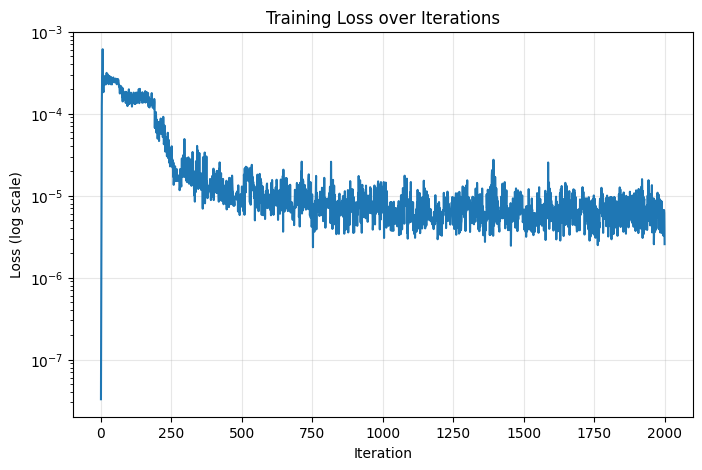

In [10]:
# plot the training loss in log scale
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss over Iterations')
plt.grid(True, alpha=0.3)
plt.show()

## SAMPLING

In [11]:
noise = torch.randn((5000, in_dim), dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    x = model(noise)

print(x.shape)

torch.Size([5000, 2])


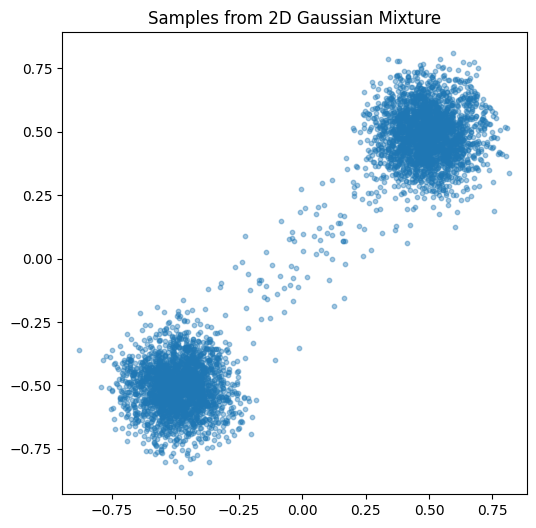

In [12]:
sampled = x.numpy()
# Plot samples and contours
plt.figure(figsize=(6, 6))
plt.scatter(sampled[:,0], sampled[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()